# Sprint 10 — Anàlisi de dades amb Pandas

## Imports

In [2]:
import pandas as pd
from datetime import datetime

# Nivell 1

## Exercici 1

Importa com un DataFrame l'arxiu `sprint10.xlsx`, assegurant-te que els noms de columnes són els correctes i sense modificar l'arxiu original. Ordena el DataFrame pel país d'origen (i per ciutat en cas d'empat) i mostra les primeres 10 files. Comprova també que el DNI només té valors únics.

In [3]:
#El fitxer original té un títol i una fila en blanc abans de la capçalera real, per això una lectura directa amb `read_excel()` no agafa bé els noms de columna. 
# Primer es localitza la fila on comença la capçalera (la que conté "Nom") i després es torna a llegir l'arxiu indicant aquesta fila com a `header`.

# Localitzem la fila on comença la capçalera real (la que conté "Nom")
raw = pd.read_excel("sprint10.xlsx", header=None)
header_row = raw[raw.iloc[:, 1] == "Nom"].index[0]

# Tornem a llegir l'arxiu amb la capçalera correcta
df = pd.read_excel("sprint10.xlsx", header=header_row)

# Eliminem la columna d'índex que arrossega l'Excel
df = df.drop(columns=["Unnamed: 0"])

df.head()

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A


In [4]:
df = df.sort_values(by=["País d'origen", "Ciutat"])
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [5]:
print("Els DNI són tots únics?", df["DNI"].is_unique)

Els DNI són tots únics? True


## Exercici 2

* Crear una columna amb el nom complet.
* Crear una columna que indiqui si la persona ha nascut a Espanya.
* Posar el DNI com a índex del DataFrame.
* Renombrar les columnes `Dia de Naixement`, `Mes de Naixement` i `Any de Naixement` a `Dia`, `Mes` i `Any`.
* Substituir els codis de gènere (`H`, `D`, `A`, `NC`) pels seus valors corresponents.

In [6]:
# Nom complet
df["Nom complet"] = df["Nom"] + " " + df["Cognoms"]

# Nascut a Espanya o no
df["Nascut Espanya"] = df["País d'origen"].apply(lambda x: "Sí" if x == "Espanya" else "No")

# DNI com a índex
df = df.set_index("DNI")

# Renombrem les columnes de la data de naixement
df = df.rename(columns={
    "Dia de Naixement": "Dia",
    "Mes de Naixement": "Mes",
    "Any de Naixement": "Any"
})

# Substituïm els codis de gènere pel seu valor real
df["Gènere"] = df["Gènere"].replace({
    "H": "Home",
    "D": "Dona",
    "A": "Altres",
    "NC": pd.NA
})

df.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No


## Exercici 3

Juntar les columnes `Fills` i `No Fills` en una sola columna `Fills`, amb valors `"Sí"` o `"No"`, fent servir `.apply()` i una funció pròpia.

In [7]:
df["Fills"] = pd.to_numeric(df["Fills"], errors="coerce")

def te_fills(fila):
    if fila["Fills"] > 0:
        return "Sí"
    else:
        return "No"

df["Fills"] = df.apply(te_fills, axis=1)
df[["Fills"]].head()

,Fills
DNI,
28973553Z,No
37399141L,Sí
37368317L,No
21390098Z,Sí
44060014R,Sí


## Exercici 4

Crear una taula resum amb el sou mig, medià, mínim i màxim per Gènere, ordenada pel sou mig.



In [8]:
#Abans cal netejar la columna `Salari mensual`, que ve com a text amb el símbol `€` i el punt com a separador de milers.
# Netejem el format de la columna Salari mensual (text -> número)
df["Salari mensual"] = (
    df["Salari mensual"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.strip()
)
df["Salari mensual"] = pd.to_numeric(df["Salari mensual"], errors="coerce")

In [9]:
resum_genere = df.groupby("Gènere")["Salari mensual"].agg(["mean", "median", "min", "max"])
resum_genere = resum_genere.sort_values(by="mean")
resum_genere

,mean,median,min,max
Gènere,,,,
Dona,1469.443182,1361.5,665,3021
Altres,1626.588235,1545.0,703,3175
Home,1643.249443,1531.0,737,3356


Les dones són les que menys guanyen de mitjana. També tenen un salari mínim més baix i un màxim més baix que els homes i altres.

## Exercici 5

Taula resum amb el salari mig per gènere (files) i país d'origen (columnes), amb les mitjanes als marges. Extra: format condicional per destacar visualment els valors més alts.

In [10]:
resum_pivot = pd.pivot_table(
    df,
    values="Salari mensual",
    index="Gènere",
    columns="País d'origen",
    aggfunc="mean",
    margins=True
).round(2)

resum_pivot

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
All,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


In [11]:
# EXTRA: format condicional per destacar els valors més elevats
resum_pivot.style.background_gradient(cmap="Blues")

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Altres,951.000000,1141.000000,1030.000000,1706.180000,nan,1423.000000,1365.000000,1372.000000,1765.000000,1921.000000,1626.590000
Dona,1804.310000,1291.800000,1497.750000,1460.160000,1566.470000,1247.180000,1405.210000,1517.800000,1488.550000,1489.460000,1469.440000
Home,2067.430000,1583.290000,1554.670000,1682.110000,1389.250000,1672.880000,1531.000000,1625.000000,1497.000000,1162.560000,1643.250000
All,1851.380000,1463.390000,1495.540000,1581.210000,1462.730000,1425.950000,1447.330000,1558.420000,1523.330000,1423.560000,1560.990000


## Exercici 6

Crear una columna amb la data de naixement en format `datetime` a partir de `Dia`, `Mes` i `Any`, i una funció per calcular l'edat actual a partir d'aquesta data.

In [12]:
df["Dia"] = pd.to_numeric(df["Dia"], errors="coerce")
df["Mes"] = pd.to_numeric(df["Mes"], errors="coerce")
df["Any"] = pd.to_numeric(df["Any"], errors="coerce")

df["Data Naixement"] = pd.to_datetime({
    "year": df["Any"],
    "month": df["Mes"],
    "day": df["Dia"]
}, errors="coerce")

df[["Dia", "Mes", "Any", "Data Naixement"]].head()

,Dia,Mes,Any,Data Naixement
DNI,,,,
28973553Z,22,10,1976,1976-10-22
37399141L,2,2,1958,1958-02-02
37368317L,23,10,2005,2005-10-23
21390098Z,11,8,1950,1950-08-11
44060014R,22,11,1985,1985-11-22


In [13]:
def calcular_edat(data_naixement):
    if pd.isna(data_naixement):
        return None
    avui = datetime.today()
    edat = avui.year - data_naixement.year
    if (avui.month, avui.day) < (data_naixement.month, data_naixement.day):
        edat -= 1
    return edat

df["Edat"] = df["Data Naixement"].apply(calcular_edat)
df[["Data Naixement", "Edat"]].head()

,Data Naixement,Edat
DNI,,
28973553Z,1976-10-22,49
37399141L,1958-02-02,68
37368317L,2005-10-23,20
21390098Z,1950-08-11,75
44060014R,1985-11-22,40


# Nivell 2

## Exercici 1

Afegir al DataFrame la columna `Increment` a partir del DataFrame `df_increment`, i actualitzar la columna `Salari mensual` aplicant el percentatge corresponent segons el Grup Professional.

In [14]:
df_increment = pd.DataFrame({
    "Grup": ["Grup A", "Grup B", "Grup C", "Grup D"],
    "Increment": ["5%", "3,5%", "2%", "8%"]
})

df = df.merge(df_increment, left_on="Grup Professional", right_on="Grup", how="left")

df["Increment"] = (
    df["Increment"]
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float) / 100
)

df["Salari mensual"] = df["Salari mensual"] * (1 + df["Increment"])

df[["Grup Professional", "Salari mensual", "Increment"]].head()

,Grup Professional,Salari mensual,Increment
0,Grup A,998.550,0.050
1,Grup B,1830.915,0.035
2,Grup B,2083.455,0.035
3,Grup B,1611.495,0.035
4,Grup D,2974.320,0.080


## Exercici 2

Exportar, amb un bucle, les dades de cada Grup Professional a un fitxer `.xlsx` independent, i exportar un cinquè fitxer amb el resum (nombre de treballadors, sou mig i edat mediana per grup).

In [15]:
for grup in df["Grup Professional"].unique():
    df_grup = df[df["Grup Professional"] == grup]
    nom_fitxer = f"dades_{grup.replace(' ', '')}.xlsx"
    df_grup.to_excel(nom_fitxer, index=False)

resum_grups = df.groupby("Grup Professional").agg({
    "Nom": "count",
    "Salari mensual": "mean",
    "Edat": "median"
})

resum_grups = resum_grups.rename(columns={
    "Nom": "Num Treballadors",
    "Salari mensual": "Sou Mig",
    "Edat": "Edat Mediana"
})

resum_grups.to_excel("resum_grups.xlsx")
resum_grups

,Num Treballadors,Sou Mig,Edat Mediana
Grup Professional,,,
Grup A,490,1213.324286,51.0
Grup B,318,1724.550849,48.0
Grup C,137,2289.192701,52.0
Grup D,55,3100.817455,44.0


El Grup D és el que té menys treballadors però el sou mig més alt i la mediana d'edat més baixa, mentre que el Grup A és el més nombrós i el que té el sou mig més baix.

# Nivell 3

Aquest nivell és independent dels anteriors: planteja dues situacions noves que no fan servir el dataset de treballadors.

## Imports d'aquest nivell

Per a aquest nivell calen llibreries noves (visualització i datasets d'exemple), que s'importen aquí per mantenir-les a prop d'on s'utilitzen.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Exercici 1 — Gràfics automàtics per columna

Funció genèrica que, donat qualsevol DataFrame, recorre totes les columnes i genera (i exporta) un gràfic adequat segons el tipus de dada:

* **Numèrica** → histograma.
* **Categòrica / text** → barres amb els valors més freqüents (top 10).
* **Data (datetime)** → barres amb els anys més freqüents.

L'objectiu no és fer gràfics polits, sinó tenir una manera ràpida d'explorar qualsevol dataset nou.

In [17]:
def explorar_columnes(df, carpeta_sortida="graphs"):
    os.makedirs(carpeta_sortida, exist_ok=True)

    for columna in df.columns:
        serie = df[columna]
        fig, ax = plt.subplots(figsize=(6, 4))

        if pd.api.types.is_datetime64_any_dtype(serie):
            serie.dt.year.value_counts().sort_index().plot(kind="bar", ax=ax)
            ax.set_title(f"Anys més freqüents - {columna}")

        elif pd.api.types.is_numeric_dtype(serie):
            serie.plot(kind="hist", ax=ax, bins=20)
            ax.set_title(f"Histograma - {columna}")

        else:
            serie.value_counts().head(10).plot(kind="bar", ax=ax)
            ax.set_title(f"Valors mes frequents - {columna}")

        fig.tight_layout()
        nom_fitxer = os.path.join(carpeta_sortida, f"{columna}.png")
        fig.savefig(nom_fitxer)
        plt.show()
        plt.close(fig)

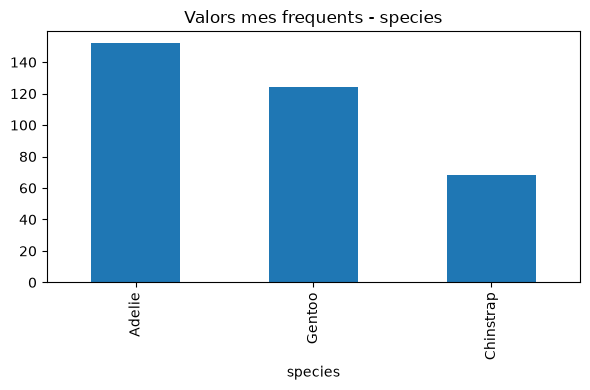

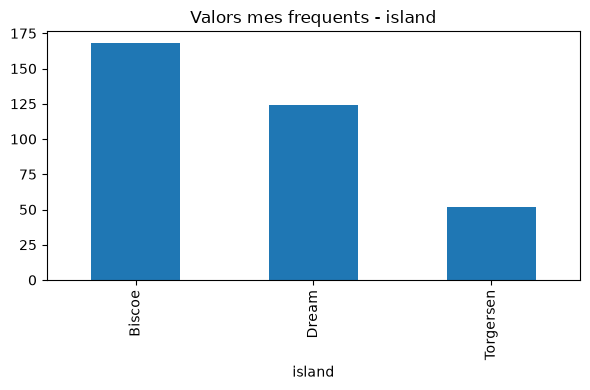

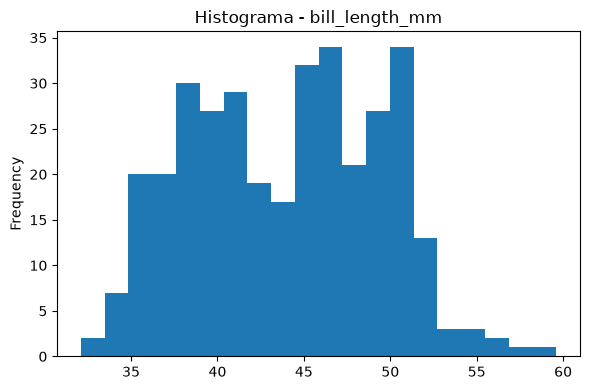

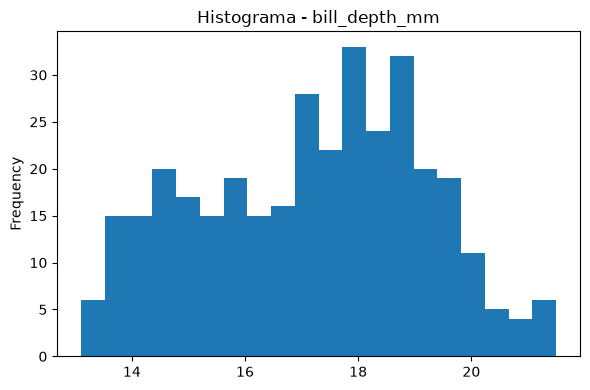

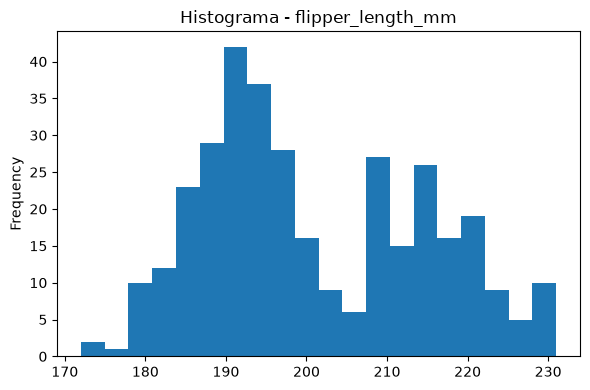

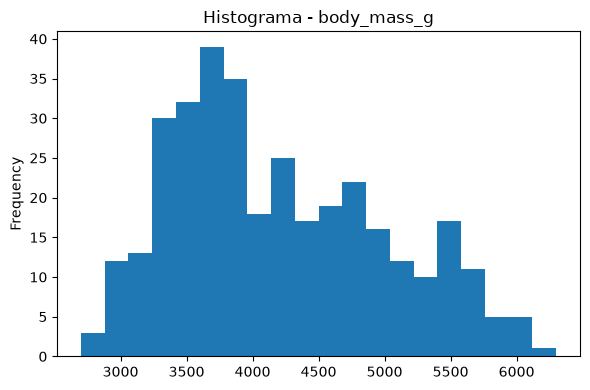

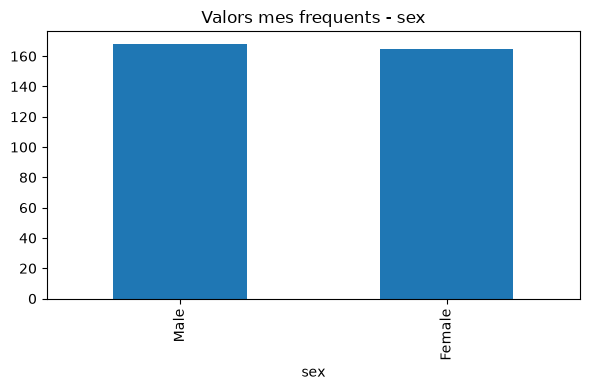

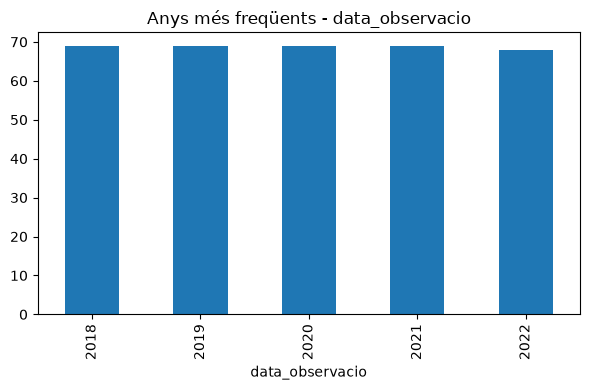

In [18]:
df_penguins = sns.load_dataset("penguins")

# Columna de data sintètica, només per demostrar el cas "datetime"
df_penguins["data_observacio"] = pd.to_datetime(
    pd.Series(range(len(df_penguins))).apply(lambda i: f"{2018 + i % 5}-01-01")
)

explorar_columnes(df_penguins)

## Exercici 2 — Ruta més curta entre ciutats

Es carrega la matriu de distàncies entre ciutats espanyoles, amb els noms de ciutat com a índex i com a columnes. S'eliminen "Las Palmas de Gran Canaria" i "Palma" perquè no és possible arribar-hi en cotxe.

In [19]:
matriu = pd.read_excel("matriu_distancies.xlsx", header=0, index_col=0)
matriu = matriu.drop(
    index=["Las Palmas de Gran Canaria", "Palma"],
    columns=["Las Palmas de Gran Canaria", "Palma"]
)
matriu.head()

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0


Per proposar una ruta es fa servir l'estratègia del veí més proper: des de la ciutat actual, sempre es va a la ciutat no visitada més propera. No és la solució òptima (el problema de visitar totes les ciutats amb la distància mínima, el "problema del viatjant", és molt costós de resoldre de manera exacta), però és una aproximació senzilla i raonable.

In [20]:
def ruta_veí_més_proper(matriu_distancies, origen):
    no_visitades = list(matriu_distancies.columns)
    no_visitades.remove(origen)

    ruta = [origen]
    ciutat_actual = origen
    distancia_total = 0

    while no_visitades:
        distancies = matriu_distancies.loc[ciutat_actual, no_visitades]
        seguent_ciutat = distancies.idxmin()

        distancia_total += distancies[seguent_ciutat]
        ruta.append(seguent_ciutat)
        no_visitades.remove(seguent_ciutat)
        ciutat_actual = seguent_ciutat

    return ruta, distancia_total

In [21]:
ruta, distancia_total = ruta_veí_més_proper(matriu, "Barcelona")

print("Ruta proposada:")
print(" -> ".join(ruta))
print()
print("Distància total:", distancia_total, "km")

Ruta proposada:
Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla -> Málaga -> Valladolid -> Gijón -> Bilbao -> Vigo

Distància total: 2778.0 km


### Extra: quin origen dona la ruta més curta amb aquest algoritme

Es repeteix el mateix càlcul començant des de cada ciutat, per veure quin punt de partida dona la distància total més curta amb aquesta estratègia.

In [22]:
distancies_per_origen = {}

for ciutat in matriu.columns:
    _, distancia = ruta_veí_més_proper(matriu, ciutat)
    distancies_per_origen[ciutat] = distancia

millor_origen = min(distancies_per_origen, key=distancies_per_origen.get)

resum_origens = pd.Series(distancies_per_origen).sort_values()
resum_origens

Barcelona                  2778.0
Hospitalet de Llobregat    2784.0
Vigo                       2873.0
Sevilla                    2956.0
Córdoba                    2981.0
Málaga                     3066.0
Murcia                     3082.0
Alicante                   3134.0
Valencia                   3200.0
Valladolid                 3357.0
Zaragoza                   3415.0
Bilbao                     3431.0
Gijón                      3439.0
dtype: float64

In [23]:
ruta_optima, distancia_optima = ruta_veí_més_proper(matriu, millor_origen)

print("Millor ciutat d'origen:", millor_origen)
print("Distància total:", distancia_optima, "km")
print(" -> ".join(ruta_optima))

Millor ciutat d'origen: Barcelona
Distància total: 2778.0 km
Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla -> Málaga -> Valladolid -> Gijón -> Bilbao -> Vigo
